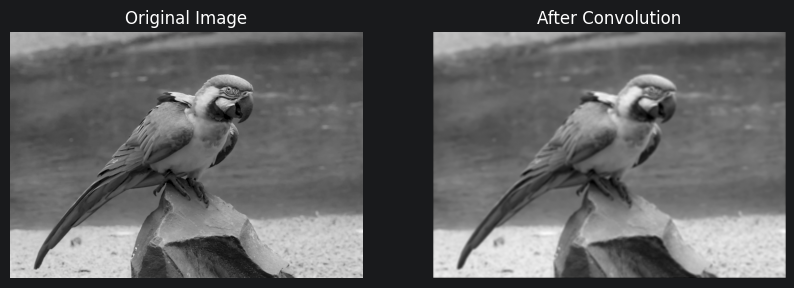

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os


img = cv2.imread(
    os.path.join('.', 'img_data', 'anhchim2.png'),
    0
)

if img is None:
    print("Không đọc được ảnh")
    exit()

# KERNEL TÍCH CHẬP
kernel = np.ones((7, 7), dtype=np.float32) / 49



# HÀM TÍCH CHẬP
def convolution(image, kernel):

    h, w = image.shape

    k = kernel.shape[0]

    pad = k // 2

    output = np.zeros((h, w), dtype=np.float32)

    # thêm padding
    padded = np.pad(image,
                    ((pad, pad), (pad, pad)),
                    mode='constant')

    for y in range(h):

        for x in range(w):

            # lấy vùng ảnh
            region = padded[y:y+k, x:x+k]

            # tích chập
            value = np.sum(region * kernel)

            output[y, x] = value

    output = np.clip(output, 0, 255)

    return output.astype(np.uint8)

# THỰC HIỆN TÍCH CHẬP

result = convolution(img, kernel)


plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(result, cmap='gray')
plt.title("After Convolution")
plt.axis("off")

plt.show()